In [1]:
import pandas as pd
import numpy as np

# Загрузка данных
ratings = pd.read_csv('ratings.csv')
books = pd.read_csv('books.csv')
tags = pd.read_csv('tags.csv')
book_tags = pd.read_csv('book_tags.csv')


### Этап 1. Улучшенная подготовка данных

In [2]:
from sklearn.preprocessing import MinMaxScaler

# Признаки пользователей
# используем скейлер, чтобы распределить активность пользователей от 0 до 1 по количеству оценок
scaler = MinMaxScaler()
user_features = ratings.groupby('user_id')['rating'].agg(mean_rating='mean',
                                                         count_ratings='count')
user_features['activity'] = scaler.fit_transform(user_features[['count_ratings']])

# ============================================================================
# УЛУЧШЕНИЕ: Создание полного датафрейма признаков книг
# ============================================================================
def create_book_features(ratings, books, book_top_genres_path='book_top_genres.csv'):
    """
    Создает полный датафрейм признаков книг:
    - Популярность (mean_rating, count_ratings)
    - Разнообразие оценок (std_rating)
    - Тематические категории (жанры)
    """
    # Статистики по рейтингам
    book_stats = ratings.groupby('book_id')['rating'].agg(
        mean_rating='mean',
        count_ratings='count',
        std_rating='std'
    ).reset_index()
    
    # Заполняем NaN для std_rating (когда только одна оценка)
    book_stats['std_rating'] = book_stats['std_rating'].fillna(0)
    
    # Загружаем жанры
    try:
        book_genres = pd.read_csv(book_top_genres_path)
        # Преобразуем список жанров в строку
        if 'genre_final' in book_genres.columns:
            book_genres['genres'] = book_genres['genre_final'].apply(
                lambda x: ', '.join(eval(x)) if isinstance(x, str) else ''
            )
            book_genres = book_genres.rename(columns={'goodreads_book_id': 'book_id'})
            book_genres = book_genres[['book_id', 'genres']]
        else:
            book_genres = pd.DataFrame(columns=['book_id', 'genres'])
    except:
        book_genres = pd.DataFrame(columns=['book_id', 'genres'])
    
    # Объединяем все признаки
    book_features = book_stats.merge(
        book_genres,
        on='book_id',
        how='left'
    )
    
    # Добавляем информацию о книгах
    book_features = book_features.merge(
        books[['book_id', 'title', 'authors']],
        on='book_id',
        how='left'
    )
    
    return book_features

# Создаем признаки книг
book_features = create_book_features(ratings, books, 'book_top_genres.csv')
print(f"✅ Создано признаков для {len(book_features)} книг")
print(f"   Средний рейтинг: {book_features['mean_rating'].mean():.2f}")
print(f"   Среднее разнообразие оценок (std): {book_features['std_rating'].mean():.2f}")
print(f"   Книг с жанрами: {book_features['genres'].notna().sum()}")


✅ Создано признаков для 10000 книг
   Средний рейтинг: 3.90
   Среднее разнообразие оценок (std): 0.93
   Книг с жанрами: 812


In [3]:
book_aggs = (
    ratings.groupby('book_id')['rating']
    .agg(mean_rating='mean',
         book_std_rating='std')
    .reset_index()
)
N_TOP_TAGS = 200
bt_named = book_tags.merge(tags, on='tag_id', how='left')
# Суммарная важность тега = сумма count по всем книгам
top_tags = (
    bt_named.groupby('tag_name')['count']
    .sum()
    .sort_values(ascending=False)
    .head(N_TOP_TAGS)
    .index
    .tolist()
)
top_tags

['to-read',
 'currently-reading',
 'favorites',
 'fiction',
 'fantasy',
 'young-adult',
 'classics',
 'books-i-own',
 'romance',
 'owned',
 'ya',
 'mystery',
 'non-fiction',
 'historical-fiction',
 'series',
 'science-fiction',
 'sci-fi',
 'paranormal',
 'kindle',
 'contemporary',
 'book-club',
 'library',
 'favourites',
 'owned-books',
 'horror',
 'default',
 'audiobook',
 'urban-fantasy',
 'nonfiction',
 'to-buy',
 'adult',
 'classic',
 'childrens',
 'graphic-novels',
 'thriller',
 'audiobooks',
 'ebook',
 'vampires',
 'adventure',
 'history',
 'dystopian',
 'audio',
 'historical',
 'humor',
 'novels',
 'chick-lit',
 'literature',
 'dystopia',
 'my-books',
 'paranormal-romance',
 'children',
 'ebooks',
 'magic',
 'crime',
 'comics',
 'i-own',
 'memoir',
 'read-in-2015',
 'adult-fiction',
 'children-s',
 'sci-fi-fantasy',
 'wish-list',
 'biography',
 'my-library',
 'read-in-2016',
 'read-in-2014',
 'children-s-books',
 'supernatural',
 'manga',
 'philosophy',
 'teen',
 'graphic-novel'

In [4]:
# Вычленим из тегов тематические теги и добавим топ 3 из них как тематику

from sentence_transformers import SentenceTransformer, util

# чистим тэги книг от мусорных тегов
stop_words = [
    'to-read', 'currently-reading', 'read', 'reading', 'reread', 're-read',
    'tbr', 'wishlist', 'wish-list', 'abandoned', 'dnf', 'unfinished', 'did-not-finish',
    'favorite', 'favourite', 'recommendations',
    'owned', 'my-book', 'my-library', 'library', 'collection', 'books-i-own', 'i-own',
    'kindle', 'ebook', 'audiobook', 'audio', 'audible', 'paperback', 'hardcover', 'edition',
    'series', 'bookclub', 'book-club', 'english', 'books', 'novel', 'default', 'own-it',
    'good', 'bad', 'best', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'tan', 'eleven',
    'close', 'a-', 'trilogy'

]
pattern = '|'.join(stop_words)

filtered_tags = tags[
    (~tags['tag_name'].str.match(r'^(\d|\-)')) &  # не начинается с цифры
    (tags['tag_name'].str.len() >= 5) &  # длина >= 3
    (~tags['tag_name'].str.contains(r'[^a-z-]')) &  # только буквы и дефисы
    (~tags['tag_name'].str.contains(r'\d')) &
    (~tags['tag_name'].str.contains(pattern, regex=True))
    ]

genre_dict = {
    "fiction": ["fiction", "literature", "novel", "prose"],
    "fantasy": ["fantasy", "magic", "dragon", "wizard", "mythology", "epic-fantasy", "urban-fantasy"],
    "sci-fi": ["science-fiction", "scifi", "sci-fi", "space", "cyberpunk", "dystopia", "utopia", "time-travel"],
    "romance": ["romance", "love", "relationship", "chick-lit", "contemporary-romance", "romantic", "erotica"],
    "mystery": ["mystery", "detective", "crime", "thriller", "suspense", "noir", "psychological-thriller"],
    "horror": ["horror", "ghost", "vampire", "zombie", "supernatural", "paranormal", "dark-fantasy"],
    "historical": ["historical", "history", "biography", "memoir", "war", "wwii"],
    "philosophy": ["philosophy", "psychology", "spirituality", "religion", "ethics"],
    "children": ["children", "kids", "picture-book", "middle-grade", "fairy-tale", "childrens"],
    "poetry": ["poetry", "verse", "haiku", "sonnet"],
    "nonfiction": ["nonfiction", "essay", "education", "science", "math", "economics", "politics", "art"],
    "graphic": ["manga", "graphic-novel", "comics", "illustration"]
}


def detect_genre_rule(tag):
    for genre, words in genre_dict.items():
        for w in words:
            if w in tag:
                return genre
    return None


filtered_tags['genre_rule'] = filtered_tags['tag_name'].apply(detect_genre_rule)

model = SentenceTransformer('all-MiniLM-L6-v2')

genre_labels = list(genre_dict.keys())
genre_embeddings = model.encode(genre_labels, convert_to_tensor=True, normalize_embeddings=True)


def detect_genre_semantic(tag):
    tag_emb = model.encode(tag, convert_to_tensor=True, normalize_embeddings=True)
    cosine_scores = util.cos_sim(tag_emb, genre_embeddings)[0]
    best_idx = int(cosine_scores.argmax())
    best_score = float(cosine_scores[best_idx])
    return genre_labels[best_idx] if best_score > 0.45 else None  # порог уверенности


filtered_tags['genre_semantic'] = filtered_tags['tag_name'].apply(detect_genre_semantic)

filtered_tags['genre_final'] = filtered_tags['genre_rule'].combine_first(filtered_tags['genre_semantic'])
filtered_tags = filtered_tags.dropna(subset=['genre_final'])

book_tags_merged = book_tags.merge(filtered_tags[['tag_id', 'genre_final']], on='tag_id', how='inner')
book_genres = (
    book_tags_merged.groupby(['goodreads_book_id', 'genre_final'])['count']
    .sum()
    .reset_index()
)
book_top_genres = (
    book_genres.sort_values(['goodreads_book_id', 'count'], ascending=[True, False])
    .groupby('goodreads_book_id')
    .head(3)  # до 3 жанров
    .groupby('goodreads_book_id')['genre_final']
    .apply(list)
    .reset_index()
)
book_top_genres.to_csv('book_top_genres.csv', index=False)
print(f"✅ Присвоено жанры для {len(book_top_genres)} книг, сохранено в book_top_genres.csv")

/Users/k0rsair/Skillfactory/recomendations itog/.venv1/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/k0rsair/Skillfactory/recomendations itog/.venv1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gt/8qzkfx097qv5qd1wscjc0rph0000gn/T/ipykernel_2904/1099772868.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_tags['genre_rule'] = filtered_tag

✅ Присвоено жанры для 10000 книг, сохранено в book_top_genres.csv


In [6]:
k = 10


def split_right_train_test(rating_df, threshhold=4, k=5):
    # Выделим только вадные оценки
    v_rating = rating_df[rating_df['rating'] >= threshhold]
    # Отделяем пользователей у которых есть валидные оценки больше или равное нужному количеству
    res = v_rating.groupby('user_id').agg({'rating': 'count'}).reset_index()
    valid_users = set(res[res['rating'] >= k * 2]['user_id'])

    valid_data = rating_df[rating_df['user_id'].isin(valid_users)]
    high_ratings = valid_data[valid_data['rating'] >= 4].copy()
    # Группируем по пользователям и для каждого выбираем k случайных записей с оценкой >= 4
    test_high_ratings = (
        high_ratings
        .groupby('user_id')
        .apply(lambda x: x.sample(n=k, random_state=42))
        .reset_index(drop=True, level=[0])  # Убираем мульти индекс сохарняя оригинальные индексы записей
    )
    test_indixes = test_high_ratings.index

    return valid_data.drop(test_indixes).reset_index(drop=True), test_high_ratings.reset_index(drop=True)


train_data, test_data = split_right_train_test(ratings, 4, k)

/var/folders/gt/8qzkfx097qv5qd1wscjc0rph0000gn/T/ipykernel_2904/2675654704.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  high_ratings


In [8]:
# Перенес класс из  прошлой дз
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

class ContentBasedRecommender:

    def __init__(self, self_book_tags, self_tags):
        self.tfidf_matrix = None
        self.vectorizer = None
        self.book_ids = None
        self.book_tags = self_book_tags
        self.tags = self_tags

    def prepare_book_profiles(self, all_books):
        # Создаем текстовые профили для книг
        book_profiles = []

        # Объединяем теги с названиями, группируем по id связи с книгой и объединяем имена тегов через пробел для создания профиля
        book_full_tags = self.book_tags.merge(self.tags, on='tag_id').groupby('goodreads_book_id').agg(
            {'tag_name': ' '.join})
        book_profiles = all_books.merge(book_full_tags, on='goodreads_book_id')
        book_profiles['original_title'] = book_profiles['original_title'].fillna(book_profiles['title'])
        book_profiles['profile'] = '' + book_profiles['original_title'] + ' ' + book_profiles['tag_name']
        return book_profiles[['profile', 'book_id']]

    def fit(self, train_books):
        # Подготавливаем профили
        book_profiles = self.prepare_book_profiles(train_books)

        # Векторизуем с помощью TF-IDF
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english',
            ngram_range=(1, 2)
        )

        self.tfidf_matrix = self.vectorizer.fit_transform(book_profiles['profile'])
        self.book_ids = book_profiles['book_id'].values

    def get_similar_books(self, book_id, n=5):
        # Находим индекс книги
        book_idx = np.where(self.book_ids == book_id)[0][0]

        # Вычисляем косинусную схожесть
        cosine_similarities = cosine_similarity(
            self.tfidf_matrix[book_idx:book_idx + 1],
            self.tfidf_matrix
        ).flatten()

        # Получаем индексы наиболее похожих книг (исключая саму книгу)
        similar_indexes = cosine_similarities.argsort()[::-1][1:n + 1]

        similar_books = []

        # Индексируем книги для быстрого получения информации о книгах
        book_indexes = books.set_index('book_id')
        for idx in similar_indexes:
            similar_book_id = self.book_ids[idx]
            similarity_score = cosine_similarities[idx]

            # Получаем информацию о книге
            book_info = book_indexes.loc[similar_book_id]
            similar_books.append({
                'book_id': similar_book_id,
                'title': book_info['original_title'] if pd.notna(book_info['original_title']) else book_info['title'],
                'similarity': similarity_score
            })

        return pd.DataFrame(similar_books)


filtered_tags_train = tags[
    (~tags['tag_name'].str.match(r'^(\d|\-)')) &  # не начинается с цифры
    (tags['tag_name'].str.len() >= 5) &  # длина >= 3
    (~tags['tag_name'].str.contains(r'[^a-z-]')) &  # только буквы и дефисы
    (~tags['tag_name'].str.contains(r'\d')) &
    (~tags['tag_name'].str.contains(pattern, regex=True))
    ]
# Инициализация и обучение контентной модели
content_model = ContentBasedRecommender(book_tags, filtered_tags_train)
content_model.fit(books)

# Тестируем на примере
book = books.iloc[0]
print(f"Похожие книги на '{book['original_title']}':")
similar_books = content_model.get_similar_books(book['book_id'], 10)
print(similar_books[['title', 'similarity']])

Похожие книги на 'The Hunger Games':
                                               title  similarity
0                                         Mockingjay    0.835699
1                                      Catching Fire    0.826830
2                           The Hunger Games Box Set    0.794616
3                     The Hunger Games Tribute Guide    0.604420
4                         The Hunger Pains: A Parody    0.595906
5  The World of the Hunger Games (Hunger Games Tr...    0.574480
6  The Hunger Games: Official Illustrated Movie C...    0.565630
7                                            Hunger     0.510761
8                           The girl who was on fire    0.486740
9                                          Insurgent    0.482561


In [9]:
class ItemBasedCF:
    def __init__(self, k=5, threshold=4):
        self.k = k
        self.user_item_matrix = None
        self.similarity_matrix = None
        self.books_rated = None
        self.threshold = threshold

    def fit(self, ratings):
        # Матрица пользователь-книга
        self.user_item_matrix = ratings.pivot_table(
            index='user_id',
            columns='book_id',
            values='rating'
        ).fillna(0)

        # Матрица схожести книг
        self.similarity_matrix = cosine_similarity(self.user_item_matrix.T)
        self.similarity_df = pd.DataFrame(
            self.similarity_matrix,
            index=self.user_item_matrix.columns,
            columns=self.user_item_matrix.columns
        )
        # Какие книги оценивал пользователь
        self.books_rated = ratings.groupby('user_id')['book_id'].apply(set)

    def predict_rating(self, user_id, book_id):
        if user_id not in self.user_item_matrix.index or book_id not in self.similarity_df.columns:
            return 0

        user_ratings = self.user_item_matrix.loc[user_id]
        book_similarities = self.similarity_df[book_id]
        rated_books = self.books_rated[user_id]

        valid_books = [b for b in rated_books if b != book_id and user_ratings[b] > 0]
        if not valid_books:
            return 0

        similar_ratings = [(book_similarities[b], user_ratings[b]) for b in valid_books]
        similar_ratings = sorted(similar_ratings, reverse=True)[:self.k]

        if not similar_ratings:
            return 0

        similarities, ratings = zip(*similar_ratings)
        weighted_sum = np.dot(similarities, ratings)
        sum_weights = np.sum(np.abs(similarities))
        return round(weighted_sum / sum_weights if sum_weights > 0 else 0, 2)

    def recommend(self, user_id, all_books, k=10, for_test=None):
        """Рекомендует top-k книг для пользователя"""
        if for_test is None:
            for_test = []
        if user_id not in self.user_item_matrix.index:
            return []

        rated = self.books_rated[user_id]
        if len(for_test) == 0:
            candidates = list(set(all_books) - rated)
        else:
            candidates = for_test[for_test['user_id'] == user_id]['book_id'].values

        # Случайный поднабор кандидатов (чтобы ускорить и не сравнивать со всеми)
        # if len(candidates) > candidate_size:
        #     candidates = random.sample(candidates, candidate_size)
        preds = []
        for b in candidates:
            pred = self.predict_rating(user_id, b)
            if pred >= self.threshold:
                preds.append((b, pred))

        sorted_preds = sorted(preds, key=lambda x: x[1], reverse=True)
        return [b for b, _ in sorted_preds[:k]]


cf_model = ItemBasedCF(k=5)
cf_model.fit(train_data)

In [11]:
res = cf_model.recommend(2, books['book_id'].unique(), for_test=test_data)
res

[25, 21, 2139, 26, 1705, 9344, 301, 15, 8034, 118]

In [12]:
#Неперсонализированная модель Popularity

class PopularityRecommender:

    def __init__(self, books, min_count_ratings=10):
        self.min_count_ratings = min_count_ratings
        self.popular_books = None
        self.books = books

    def fit(self, ratings):
        # Вычисляем средний рейтинг с минимальным количеством оценок
        book_stats = ratings.groupby('book_id').agg({
            'rating': ['count', 'mean']
        }).round(2)
        book_stats.columns = ['count', 'mean_rating']
        # Фильтруем по минимальному количеству оценок
        qualified_books = book_stats[book_stats['count'] >= self.min_count_ratings]
        # Сортируем по среднему рейтингу
        self.popular_books = qualified_books.sort_values('mean_rating', ascending=False)
        # Добавляем информацию о книгах
        self.popular_books = self.popular_books.merge(
            self.books[['book_id', 'original_title', 'title']],
            on='book_id'
        )

    def recommend(self, n=10):
        return self.popular_books.head(n)


# Инициализация и обучение модели популярности
pop_model = PopularityRecommender(books=books, min_count_ratings=7000)
pop_model.fit(train_data)
print("Топ-10 популярных книг:")
display(pop_model.recommend(10))


Топ-10 популярных книг:


,book_id,count,mean_rating,original_title,title
0,25,13365,4.51,Harry Potter and the Deathly Hallows,Harry Potter and the Deathly Hallows (Harry Po...
1,27,13205,4.42,Harry Potter and the Half-Blood Prince,Harry Potter and the Half-Blood Prince (Harry ...
2,24,13622,4.41,Harry Potter and the Goblet of Fire,Harry Potter and the Goblet of Fire (Harry Pot...
3,18,13923,4.40,Harry Potter and the Prisoner of Azkaban,Harry Potter and the Prisoner of Azkaban (Harr...
4,31,11071,4.36,The Help,The Help
5,21,13469,4.33,Harry Potter and the Order of the Phoenix,Harry Potter and the Order of the Phoenix (Har...
6,2,18502,4.31,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...
7,39,9324,4.31,A Game of Thrones,"A Game of Thrones (A Song of Ice and Fire, #1)"
8,47,9209,4.28,The Book Thief,The Book Thief
9,50,7332,4.28,Where the Sidewalk Ends: The Poems and Drawing...,Where the Sidewalk Ends


In [13]:
from surprise import Dataset, Reader, SVD

class MatrixFactorizationRecommender:

    def __init__(self, all_books_data, n_factors=50, n_epochs=20, lr=0.005, reg=0.02, threshold=4):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        # Инициализируем модель SVD
        self.model = SVD(
            n_factors=self.n_factors,
            n_epochs=self.n_epochs,
            lr_all=self.lr,
            reg_all=self.reg
        )
        self.threshold = threshold
        self.ratings = None
        self.books = all_books_data

    def fit(self, train_set):
        data = self.prepare_data(train_set)
        self.model.fit(data.build_full_trainset())
        self.ratings = train_set

    def prepare_data(self, df_items):
        return Dataset.load_from_df(df_items[['user_id', 'book_id', 'rating']], reader)

    def predict_rating(self, user_id, book_id):
        try:
            prediction = self.model.predict(user_id, book_id)
            return prediction.est
        except:
            return 0

    def get_recommendations(self, user_id, n=5, for_test=None):
        # Получаем все книги, которые пользователь не оценивал
        rated_books = set(self.ratings[self.ratings['user_id'] == user_id]['book_id'])
        if for_test is not None:
            unrated_books = for_test[for_test['user_id'] == user_id]['book_id'].unique().tolist()
        else:
            unrated_books = set(self.books['book_id']) - rated_books

        # Предсказываем рейтинги
        predictions = []
        for book_id in list(unrated_books):
            pred_rating = self.predict_rating(user_id, book_id)
            if pred_rating > self.threshold:
                predictions.append((book_id, pred_rating))

        # Сортируем по предсказанному рейтингу
        predictions.sort(key=lambda x: x[1], reverse=True)
        # Добавляем информацию о книгах
        recommendations = []
        book_indexed = self.books.set_index('book_id')
        for book_id, rating in predictions[:n]:
            book_info = book_indexed.loc[book_id]
            recommendations.append({
                'book_id': book_id,
                'title': book_info['original_title'],
                'predicted_rating': rating
            })

        return pd.DataFrame(recommendations)


# Подготавливаем данные для Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'book_id', 'rating']], reader)

svd_model = MatrixFactorizationRecommender(books, n_factors=20, n_epochs=10)
svd_model.fit(train_data)

In [11]:
res = svd_model.get_recommendations(6, 10, test_data)
check_items = test_data[test_data['user_id'] == 1]['book_id'].tolist()


In [15]:
# Разделение пользователей на типы (новые/активные)
def classify_user_type(user_id, ratings, threshold_new=5, threshold_active=20):
    """
    Классифицирует пользователя по типу:
    - 'new': новые пользователи (< threshold_new оценок)
    - 'medium': среднеактивные (threshold_new <= оценки < threshold_active)
    - 'active': активные (>= threshold_active оценок)
    """
    user_ratings_count = len(ratings[ratings['user_id'] == user_id])
    
    if user_ratings_count < threshold_new:
        return 'new'
    elif user_ratings_count < threshold_active:
        return 'medium'
    else:
        return 'active'


def get_user_type_weights(user_type):
    """
    Возвращает веса для гибридной модели в зависимости от типа пользователя.
    Логика:
    - Новые пользователи: больше веса на Popularity и Content (не требуют истории)
    - Активные пользователи: больше веса на SVD и ItemCF (используют историю)
    """
    if user_type == 'new':
        return dict(
            svd=0.1,      # Мало данных для SVD
            itemcf=0.1,   # Мало данных для ItemCF
            cont=0.4,     # Контент работает без истории
            pop=0.4       # Популярность всегда работает
        )
    elif user_type == 'medium':
        return dict(
            svd=0.2,
            itemcf=0.3,
            cont=0.3,
            pop=0.2
        )
    else:  # active
        return dict(
            svd=0.3,      # Много данных для SVD
            itemcf=0.5,   # Много данных для ItemCF
            cont=0.1,
            pop=0.1
        )


In [16]:
# получим схожести книг с историей пользователя

import os
from tqdm import tqdm
from scipy import sparse as sp

tfidf_matrix = content_model.tfidf_matrix
book_ids = content_model.book_ids  # порядок соответствующий tfidf_matrix
book_id_to_idx = {bid: i for i, bid in enumerate(book_ids)}


# Создаём профиль пользователя
def get_user_profile_vector(user_id, ratings, book_id_to_idx, tfidf_matrix, threshold=4):
    """Возвращает средний TF-IDF вектор книг, которым пользователь поставил >= threshold."""
    liked_books = ratings.loc[
        (ratings['user_id'] == user_id) & (ratings['rating'] >= threshold),
        'book_id'
    ]
    indices = [book_id_to_idx[b] for b in liked_books if b in book_id_to_idx]
    if not indices:
        return None
    # усредняем по строкам sparse-матрицы; mean(axis=0) часто даёт np.matrix
    user_vector = tfidf_matrix[indices].mean(axis=0)
    # Приводим к формату 1 x n_features CSR
    if sp.issparse(user_vector):
        user_vector = user_vector.tocsr()
    else:
        # np.matrix или ndarray -> CSR
        user_vector = sp.csr_matrix(np.asarray(user_vector))
    return user_vector


# Функция для вычисления схожести
def compute_similarity_features(ratings, tfidf_matrix, book_id_to_idx, filepath='interaction_features.csv.gz'):
    """
    Вычисляет косинусную схожесть книги с историей пользователя.
    Если файл существует, загружает данные из него. Иначе вычисляет и сохраняет.
    """
    # Проверяем наличие файла
    if os.path.exists(filepath):
        print(f"📂 Файл {filepath} найден, загружаем данные...")
        df_features = pd.read_csv(filepath)
        print(f"✅ Загружено {len(df_features)} строк из {filepath}")
        return df_features
    
    # Если файла нет, вычисляем
    print("🔄 Файл не найден, начинаем вычисления...")
    features = []
    unique_users = ratings['user_id'].unique()

    print(f"🔍 Building user profiles for {len(unique_users)} users...")

    # создаём профили пользователей
    user_profiles = {}
    for uid in tqdm(unique_users):
        user_profiles[uid] = get_user_profile_vector(uid, ratings, book_id_to_idx, tfidf_matrix)

    print("Computing similarities for user-book pairs...")

    for row in tqdm(ratings.itertuples(index=False), total=len(ratings)):
        uid = row.user_id
        bid = row.book_id
        profile = user_profiles.get(uid)
        if profile is None or bid not in book_id_to_idx:
            sim = np.nan
        else:
            book_vec = tfidf_matrix[book_id_to_idx[bid]]
            # cosine_similarity умеет работать со sparse матрицами; оба вектора гарантировано 1 x n_features CSR
            sim = cosine_similarity(profile, book_vec)[0, 0]
        features.append((uid, bid, sim))

    df_features = pd.DataFrame(features, columns=['user_id', 'book_id', 'sim_with_history'])
    
    # Сохраняем в сжатом виде для экономии места
    # При чтении используйте: pd.read_csv('interaction_features.csv.gz') - pandas автоматически распакует
    df_features.to_csv(filepath, index=False, compression='gzip')
    print(f"✅ interaction_features.csv.gz сохранён (сжатый): {len(df_features)} строк")
    
    return df_features


interaction_features = compute_similarity_features(ratings, tfidf_matrix, book_id_to_idx)
print(interaction_features.head())

📂 Файл interaction_features.csv.gz найден, загружаем данные...
✅ Загружено 5976479 строк из interaction_features.csv.gz
   user_id  book_id  sim_with_history
0        1      258          0.442258
1        2     4081          0.254906
2        2      260          0.583715
3        2     9296          0.439351
4        2     2318          0.430437


### Этап 2

In [25]:
# Класс для гибридной системы
import numpy as np
import pandas as pd
from sklearn.preprocessing import minmax_scale

class HybridRecommender:
    def __init__(self, ratings, books, content_model, item_cf_model, svd_model, popularity_df):
        self.ratings = ratings
        self.books = books
        self.content_model = content_model
        self.item_cf_model = item_cf_model
        self.svd_model = svd_model
        self.popularity_df = popularity_df
        self.threshold_new = 5
        self.threshold_active = 20

        # веса (warm user)
        self.weights = dict(
            svd=0.3,
            itemcf=0.5,
            cont=0.10,
            pop=0.10
        )

    def _normalize_scores(self, df, col='score'):
        """MinMax нормализация по пользователю"""
        df = df.copy()
        if len(df) == 0:
            return df
        df[col] = minmax_scale(df[col].astype(float))
        return df

    def get_candidates_popularity(self, M=500):

        return self.popularity_df.recommend(M)[['book_id', 'mean_rating']].rename(columns={'mean_rating': 'score'})

    def get_candidates_content(self, user_id, M=500):
        """Находим топ похожих книг к понравившимся пользователю"""
        liked_books = self.ratings[(self.ratings['user_id'] == user_id) & (self.ratings['rating'] >= 4)][
            'book_id'].unique()
        all_cands = pd.DataFrame()
        for b in liked_books:
            try:
                sims = self.content_model.get_similar_books(b, n=50)[['book_id', 'similarity']]
                all_cands = pd.concat([all_cands, sims])
            except Exception:
                continue
        if all_cands.empty:
            return all_cands
        all_cands = all_cands.groupby('book_id')['similarity'].max().reset_index()
        all_cands = self._normalize_scores(all_cands, 'similarity')
        all_cands.rename(columns={'similarity': 'score'}, inplace=True)
        return all_cands.sort_values('score', ascending=False).head(M)

    def get_candidates_itemcf(self, user_id, M=500, test_data=None):
        """Item-based CF"""
        recs = self.item_cf_model.recommend(user_id, self.books['book_id'].unique(), k=M, for_test=test_data)
        if not recs:
            return pd.DataFrame(columns=['book_id', 'score'])
        df = pd.DataFrame(recs, columns=['book_id'])
        # модель возвращает список id, добавим псевдо-скор (ранг)
        df['score'] = np.linspace(1, 0, len(df))
        df = self._normalize_scores(df)

        return df.head(M)

    def get_candidates_svd(self, user_id, M=500, test_data=None):
        """Предсказания из SVD"""
        preds = self.svd_model.get_recommendations(user_id, n=M, for_test=test_data)
        df = self._normalize_scores(preds, 'predicted_rating')
        if 'predicted_rating' not in df.columns:
            return pd.DataFrame(columns=['book_id', 'score'])

        df.rename(columns={'predicted_rating': 'score'}, inplace=True)
        return df.sort_values('score', ascending=False).head(M)

    def recommend(self, user_id, K=10, M=500, for_test=None):
        """Объединяет кандидатов из всех моделей с адаптивными весами"""
        candidates = []

        # переопределим K
        self.item_cf_model.k = K

        # Popularity
        pop = self.get_candidates_popularity(M)
        pop['model'] = 'pop'
        candidates.append(pop)

        # Content
        cont = self.get_candidates_content(user_id, M)
        cont['model'] = 'cont'
        candidates.append(cont)

        # ItemCF
        itemcf = self.get_candidates_itemcf(user_id, M, for_test)
        itemcf['model'] = 'itemcf'
        candidates.append(itemcf)

        # SVD
        svd = self.get_candidates_svd(user_id, M, for_test)
        svd['model'] = 'svd'
        candidates.append(svd)

        candidates = [c for c in candidates if c is not None and not c.empty]
        # Объединяем
        all_cands = pd.concat(candidates)
        all_cands = (
            all_cands
            .groupby(['book_id', 'model'], as_index=False)['score']
            .sum()
            .pivot(index='book_id', columns='model', values='score')
            .fillna(0)
            .reset_index()
        )

        for col in list(self.weights):
            if col not in all_cands.columns:
                all_cands[col] = 0.0

        # Используем адаптивные веса в зависимости от типа пользователя
        adaptive_weights = self._get_adaptive_weights(user_id)
        # Удаляем уже прочитанные
        return self.calc_score(all_cands, user_id, K, adaptive_weights)

    def calc_score(self, all_cands, user_id, K, weights=None):

        read_books = self.ratings[self.ratings['user_id'] == user_id]['book_id'].unique()
        all_cands = all_cands[~all_cands['book_id'].isin(read_books)]
        if weights is None:
            weights = self.weights

        # Взвешенная сумма
        all_cands = all_cands.copy()
        all_cands['hybrid_score'] = (
                weights['svd'] * all_cands['svd'] +
                weights['itemcf'] * all_cands['itemcf'] +
                weights['cont'] * all_cands['cont'] +
                weights['pop'] * all_cands['pop']
        )

        top_k = all_cands.sort_values('hybrid_score', ascending=False).head(K)

        # Балансировка между релевантностью и разнообразием
        book_id_to_idx = {bid: i for i, bid in enumerate(self.content_model.book_ids)}
        top_k = self.cons_relevance(top_k, self.content_model.tfidf_matrix, book_id_to_idx, lambda_div=0.7, top_k=K)

        return top_k.merge(self.books[['book_id', 'title', 'authors']], on='book_id', how='left')

    def cons_relevance(self, candidates, tfidf_matrix, book_id_to_idx, lambda_div=0.7, top_k=10):
        """
        Применяет Maximal Marginal Relevance (MMR) для выбора разнообразного топа.
        candidates: DataFrame с колонками ['book_id', 'hybrid_score']
        """
        selected = []
        candidate_ids = candidates['book_id'].tolist()
        candidate_scores = candidates.set_index('book_id')['hybrid_score'].to_dict()

        # получаем tf-idf вектора для кандидатов
        valid_ids = [b for b in candidate_ids if b in book_id_to_idx]
        if not valid_ids:
            return candidates.head(top_k)

        while len(selected) < top_k and valid_ids:
            best_doc = None
            best_mmr = -np.inf

            for b in valid_ids:
                rel = candidate_scores.get(b, 0)
                if not selected:
                    mmr_score = rel
                else:
                    selected_vecs = tfidf_matrix[[book_id_to_idx[s] for s in selected]]
                    sim_to_selected = cosine_similarity(
                        tfidf_matrix[book_id_to_idx[b]], selected_vecs
                    ).max()
                    mmr_score = lambda_div * rel - (1 - lambda_div) * sim_to_selected

                if mmr_score > best_mmr:
                    best_mmr = mmr_score
                    best_doc = b

            selected.append(best_doc)
            valid_ids.remove(best_doc)

        return candidates[candidates['book_id'].isin(selected)]

    def _get_user_type(self, user_id):
        """Определяет тип пользователя"""
        user_ratings_count = len(self.ratings[self.ratings['user_id'] == user_id])
        threshold_new = getattr(self, 'threshold_new', 5)
        threshold_active = getattr(self, 'threshold_active', 20)

        if user_ratings_count < threshold_new:
            return 'new'
        elif user_ratings_count < threshold_active:
            return 'medium'
        else:
            return 'active'

    def _get_adaptive_weights(self, user_id):
        """Возвращает адаптивные веса для пользователя"""
        user_type = self._get_user_type(user_id)
        return get_user_type_weights(user_type)

In [32]:

hybrid = HybridRecommender(
    ratings=train_data,
    books=books,
    content_model=content_model,
    item_cf_model=cf_model,
    svd_model=svd_model,
    popularity_df=pop_model
)

hybrid.recommend(user_id=6, K=10, for_test=test_data)

,book_id,cont,itemcf,pop,svd,hybrid_score,title,authors
0,1265,0.729459,0.833333,0.00,1.000000,0.789613,Maus II: A Survivor's Tale: And Here My Troubl...,Art Spiegelman
1,2357,0.731619,1.000000,0.00,0.540570,0.735333,The Botany of Desire: A Plant's-Eye View of th...,Michael Pollan
2,82,0.603017,0.666667,0.00,0.344881,0.497099,Into the Wild,Jon Krakauer
3,4079,0.597825,0.500000,0.00,0.547758,0.474110,The Mother Tongue: English and How It Got That...,Bill Bryson
4,25,0.000000,0.000000,4.51,0.000000,0.451000,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré"
5,27,0.000000,0.000000,4.42,0.000000,0.442000,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
6,24,0.000000,0.000000,4.41,0.000000,0.441000,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPré"
7,18,0.000000,0.000000,4.40,0.000000,0.440000,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck"
8,31,0.000000,0.000000,4.36,0.000000,0.436000,The Help,Kathryn Stockett
9,21,0.000000,0.000000,4.33,0.000000,0.433000,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré"


### Этап 3

In [33]:
# Метрики
def get_recs_for_model(model, user_id, K, ratings, books, test_ratings):
    """
    Приводит разные модели к единому интерфейсу.
    Возвращает список book_id длиной <= K.
    """
    read = set(ratings.loc[ratings['user_id'] == user_id, 'book_id'])

    model_name = type(model).__name__

    if hasattr(model, 'recommend') and model_name == 'HybridRecommender':
        df = model.recommend(user_id=user_id, K=K, for_test=test_ratings)
        return [int(b) for b in df['book_id'].tolist()][:K]

    if model_name == 'PopularityRecommender':
        df = model.recommend(n=K * 3).copy()  # небольшой запас
        if 'book_id' not in df.columns:
            return []
        df = df[~df['book_id'].isin(read)]
        return [int(b) for b in df['book_id'].head(K).tolist()]

    if model_name == 'ContentBasedRecommender':
        liked = ratings.query('user_id == @user_id and rating >= 4')['book_id'].unique()
        ids = []
        for b in liked:  # ограничим 10 книг для скорости
            try:
                sims = model.get_similar_books(int(b), n=K)
                ids.extend(sims['book_id'].tolist())
            except Exception:
                continue
        # uniq и фильтрация прочитанного
        uniq, seen = [], set()
        for x in ids:
            if x not in read and x not in seen:
                uniq.append(int(x))
                seen.add(x)
                if len(uniq) >= K:
                    break
        return uniq

    if model_name == 'ItemBasedCF':
        all_books = books['book_id'].unique()
        ids = model.recommend(user_id, all_books, k=K * 3, for_test=test_ratings)
        ids = [int(b) for b in ids if b not in read]
        return ids[:K]

    if model_name == 'MatrixFactorizationRecommender':
        df = model.get_recommendations(user_id, n=K * 3, for_test=test_ratings)
        if 'book_id' not in df.columns:
            return []
        df = df[~df['book_id'].isin(read)]
        return [int(b) for b in df['book_id'].head(K).tolist()]

    # Фолбэк: generic recommend
    if hasattr(model, 'recommend'):
        try:
            df = model.recommend(user_id, K)
            if isinstance(df, list):
                return [int(b) for b in df][:K]
            if hasattr(df, 'columns') and 'book_id' in df.columns:
                return [int(b) for b in df['book_id'].tolist()][:K]
        except Exception:
            return []
    return []


def get_metrics(recommended, relevant, k):
    inter = len(set(recommended[:k]) & set(relevant))
    precision = inter / float(k)
    recall = inter / float(len(relevant)) if relevant else 0.0

    # nDCG@K (бинарная релевантность)
    rel_scores = {int(b): 1 for b in relevant}
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        rel = rel_scores.get(int(item), 0)
        dcg += (2 ** rel - 1) / np.log2(i + 2)
        idcg = sum([(2 ** 1 - 1) / np.log2(i + 2) for i in range(min(len(relevant), k))])
        ndcg = (dcg / idcg) if idcg > 0 else 0.0

    return precision, recall, ndcg


def evaluate_model(model, train_ratings, test_users, test_ratings, k=10):
    """
    Вычисляет Precision@K, Recall@K и nDCG@K для модели.
    Устойчив к случаям, когда модель ничего не вернула (ставит 0, не NaN).
    """
    precision_list, recall_list, ndcg_list = [], [], []

    for uid in tqdm(test_users, desc=f"Evaluating {type(model).__name__}"):
        # релевантные книги = рейтинг >= 4
        relevant = test_ratings[(test_ratings['user_id'] == uid) & (test_ratings['rating'] >= 4)]['book_id'].tolist()
        if not relevant:
            continue  # пропускаем совсем «пустых» пользователей

        recommended = get_recs_for_model(model, uid, k, train_ratings, books, test_ratings)
        if not recommended:
            precision_list.append(0.0)
            recall_list.append(0.0)
            ndcg_list.append(0.0)
            continue

        precision, recall, ndcg = get_metrics(recommended, relevant, k)
        precision_list.append(precision)
        recall_list.append(recall)
        ndcg_list.append(ndcg)

    if not precision_list:
        return {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0}

    return {
        'precision@k': float(np.mean(precision_list)),
        'recall@k': float(np.mean(recall_list)),
        'ndcg@k': float(np.mean(ndcg_list))
    }


def optimize_weights_cached(hibrid: HybridRecommender, cache, test_users, test_ratings, k=10, metric_weights=(0.6, 0.2, 0.2), return_trials=False):
    """
    Подбирает веса гибрида по составной метрике: score = a*nDCG + b*Precision + c*Recall.
    - cache: dict[user_id] -> DataFrame(['book_id','svd','itemcf','cont','pop'])
    - metric_weights: (a, b, c) — веса метрик
    - Возвращает (best_weights, best_score[, trials_df])
    """
    a, b, c = metric_weights
    best_score, best_weights = -1.0, None
    trials = []

    grid = np.linspace(0.0, 1.0, 11)  # 0.0 ... 1.0 с шагом 0.1

    print("Начало расчета весов")
    for w_svd in grid:
        for w_item in grid:
            for w_cont in grid:
                s = w_svd + w_item + w_cont
                if s > 1.0:
                    continue
                w_pop = 1.0 - s
                weights = dict(svd=w_svd, itemcf=w_item, cont=w_cont, pop=w_pop)

                precs, recs, ndcgs = [], [], []

                for uid in tqdm(test_users, desc="Считаем метрики", leave=False):
                    df = cache.get(uid)
                    if df is None or df.empty:
                        continue
                    df = df.copy()

                    # гарантируем колонки
                    for col in ['svd', 'itemcf', 'cont', 'pop']:
                        if col not in df.columns:
                            df[col] = 0.0
                    topk = hibrid.calc_score(df, uid, k, weights)
                    # гибридный скор
                    relevant = test_ratings[(test_ratings['user_id'] == uid) & (test_ratings['rating'] >= 4)]['book_id'].tolist()
                    precision, recall, ndcg = get_metrics(topk['book_id'].tolist(), relevant, k)

                    precs.append(precision)
                    recs.append(recall)
                    ndcgs.append(ndcg)

                mean_p = float(np.mean(precs))
                mean_r = float(np.mean(recs))
                mean_n = float(np.mean(ndcgs))

                composite = a * mean_n + b * mean_p + c * mean_r
                trials.append({
                    'w_svd': w_svd, 'w_itemcf': w_item, 'w_cont': w_cont, 'w_pop': w_pop,
                    'precision@k': mean_p, 'recall@k': mean_r, 'ndcg@k': mean_n,
                    'composite': composite
                })

                if composite > best_score:
                    best_score = composite
                    best_weights = weights.copy()

    trials_df = pd.DataFrame(trials)
    if return_trials:
        return best_weights, best_score, trials_df.sort_values('composite', ascending=False)
    return best_weights, best_score


def build_cache(hybrid, test_users, test_data):
    """Вычисляет кандидатов всех моделей один раз и кэширует результат в файл."""
    import os
    if os.path.exists('cache_precomputed.pkl'):
        print("Загружен кэш из cache_precomputed.pkl")
        return pd.read_pickle('cache_precomputed.pkl')
    cache = {}
    print("Формируем кэш...")
    for uid in tqdm(test_users, desc="Building cache"):
        cands = []

        pop = hybrid.get_candidates_popularity()
        pop['model'] = 'pop'
        cands.append(pop)

        cont = hybrid.get_candidates_content(uid)
        cont['model'] = 'cont'
        cands.append(cont)

        itemcf = hybrid.get_candidates_itemcf(uid, test_data=test_data)
        itemcf['model'] = 'itemcf'
        cands.append(itemcf)

        svd = hybrid.get_candidates_svd(uid, test_data=test_data)
        svd['model'] = 'svd'
        cands.append(svd)

        cands = [c for c in cands if not c.empty]
        all_cands = pd.concat(cands)
        all_cands = (
            all_cands.groupby(['book_id', 'model'])['score']
            .sum().unstack(fill_value=0).reset_index()
        )
        # Сохраняем кэш после обработки каждого пользователя
        cache[uid] = all_cands
        pd.to_pickle(cache, 'cache_precomputed.pkl')
    return cache

In [34]:
# Метрики
np.random.seed(42)
users_with_rel = test_data.loc[test_data['rating'] >= 4, 'user_id'].unique()
users_in_train = train_data['user_id'].unique()
eligible_users = np.intersect1d(users_with_rel, users_in_train)
num_sample = min(300, len(eligible_users))
if num_sample == 0:
    raise ValueError(
        "Нет пользователей с релевантными оценками в тесте и присутствующих в трейне. Расширьте тест или снизьте порог.")
test_users = np.random.choice(eligible_users, num_sample, replace=False)

len(test_users)

300

🔍 Анализ эффективности гибридной модели по сегментам пользователей...


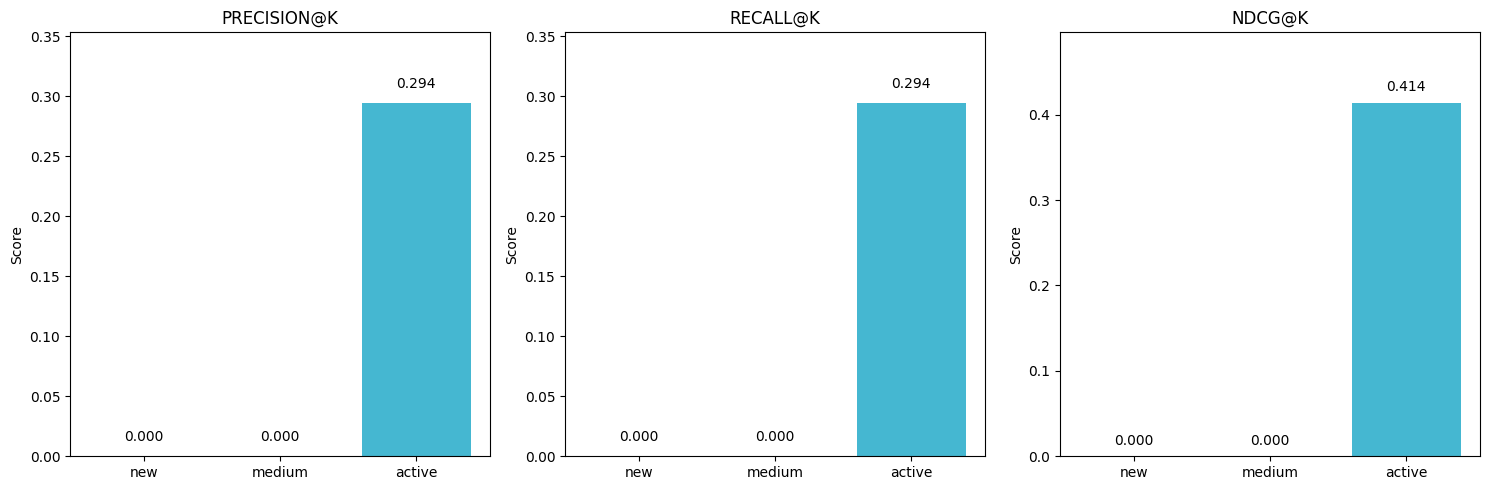


📊 Результаты по сегментам пользователей:
        precision@k  recall@k  ndcg@k  count
new          0.0000    0.0000  0.0000    0.0
medium       0.0000    0.0000  0.0000    1.0
active       0.2943    0.2943  0.4136  299.0

📊 Распределение пользователей по сегментам:
active    299
medium      1
Name: count, dtype: int64


In [35]:
def evaluate_by_user_segments(model, train_data, test_users, test_data,
                               ratings, k=10, threshold_new=5, threshold_active=20):
    """
    Оценивает модель отдельно для разных сегментов пользователей.
    
    Возвращает:
    - results_by_segment: словарь с метриками по сегментам
    - user_segments: распределение пользователей по сегментам
    """
    # Классифицируем пользователей
    user_segments = {}
    for uid in test_users:
        user_type = classify_user_type(uid, train_data, threshold_new, threshold_active)
        user_segments[uid] = user_type
    
    # Группируем по сегментам
    segments = {
        'new': [uid for uid, seg in user_segments.items() if seg == 'new'],
        'medium': [uid for uid, seg in user_segments.items() if seg == 'medium'],
        'active': [uid for uid, seg in user_segments.items() if seg == 'active']
    }
    
    results_by_segment = {}
    
    for segment_name, segment_users in segments.items():
        if len(segment_users) == 0:
            results_by_segment[segment_name] = {
                'precision@k': 0.0,
                'recall@k': 0.0,
                'ndcg@k': 0.0,
                'count': 0
            }
            continue
        
        precision_list, recall_list, ndcg_list = [], [], []
        
        for uid in tqdm(segment_users, desc=f"Evaluating {segment_name} users", leave=False):
            try:
                # Получаем рекомендации
                if hasattr(model, 'recommend'):
                    recs = model.recommend(uid, K=k, for_test=test_data)
                    if isinstance(recs, pd.DataFrame) and 'book_id' in recs.columns:
                        recommended = recs['book_id'].tolist()
                    else:
                        recommended = recs if isinstance(recs, list) else []
                else:
                    continue
                
                # Получаем релевантные книги (rating >= 4)
                relevant = test_data[
                    (test_data['user_id'] == uid) & 
                    (test_data['rating'] >= 4)
                ]['book_id'].tolist()
                
                if not relevant:
                    continue
                
                # Вычисляем метрики
                if len(recommended) > 0:
                    # Precision@k
                    hits = len(set(recommended[:k]) & set(relevant))
                    precision = hits / min(k, len(recommended))
                    
                    # Recall@k
                    recall = hits / len(relevant) if len(relevant) > 0 else 0
                    
                    # nDCG@k (упрощенная версия)
                    dcg = 0
                    for i, book_id in enumerate(recommended[:k]):
                        if book_id in relevant:
                            dcg += 1 / np.log2(i + 2)
                    idcg = sum(1 / np.log2(i + 2) for i in range(min(k, len(relevant))))
                    ndcg = dcg / idcg if idcg > 0 else 0
                    
                    precision_list.append(precision)
                    recall_list.append(recall)
                    ndcg_list.append(ndcg)
            except Exception as e:
                continue
        
        if precision_list:
            results_by_segment[segment_name] = {
                'precision@k': float(np.mean(precision_list)),
                'recall@k': float(np.mean(recall_list)),
                'ndcg@k': float(np.mean(ndcg_list)),
                'count': len(segment_users)
            }
        else:
            results_by_segment[segment_name] = {
                'precision@k': 0.0,
                'recall@k': 0.0,
                'ndcg@k': 0.0,
                'count': len(segment_users)
            }
    
    return results_by_segment, user_segments


def visualize_segment_results(results_by_segment):
    """Создает визуализацию результатов по сегментам"""
    import matplotlib.pyplot as plt
    
    segments = list(results_by_segment.keys())
    metrics = ['precision@k', 'recall@k', 'ndcg@k']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, metric in enumerate(metrics):
        values = [results_by_segment[seg].get(metric, 0) for seg in segments]
        axes[idx].bar(segments, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[idx].set_title(f'{metric.upper()}')
        axes[idx].set_ylabel('Score')
        axes[idx].set_ylim(0, max(values) * 1.2 if max(values) > 0 else 1)
        for i, v in enumerate(values):
            axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Таблица результатов
    results_df = pd.DataFrame(results_by_segment).T
    print("\n📊 Результаты по сегментам пользователей:")
    print(results_df.round(4))
    
    return results_df


# Анализ гибридной модели по сегментам
print("🔍 Анализ эффективности гибридной модели по сегментам пользователей...")
results_by_segment, user_segments = evaluate_by_user_segments(
    hybrid, 
    train_data, 
    test_users, 
    test_data,
    train_data,
    k=10
)

# Визуализация
results_segment_df = visualize_segment_results(results_by_segment)

# Статистика по сегментам
segment_counts = pd.Series(user_segments).value_counts()
print(f"\n📊 Распределение пользователей по сегментам:")
print(segment_counts)

In [36]:
results = {}
print("🔍 Сравниваем модели...")
results['Popularity'] = evaluate_model(pop_model, train_data, test_users, test_data)
results['Content'] = evaluate_model(content_model, train_data, test_users, test_data)
results['ItemCF'] = evaluate_model(cf_model, train_data, test_users, test_data)
results['SVD'] = evaluate_model(svd_model, train_data, test_users, test_data)
results['Hybrid'] = evaluate_model(hybrid, train_data, test_users, test_data)
results_df = pd.DataFrame(results).T.round(4)
display(results_df.style.highlight_max(color='lightgreen'))


🔍 Сравниваем модели...


Evaluating HybridRecommender: 100%|██████████| 300/300 [02:52<00:00,  1.74it/s]


,precision@k,recall@k,ndcg@k
Popularity,0.051300,0.051300,0.060200
Content,0.042300,0.042300,0.054500
ItemCF,0.556700,0.556700,0.647000
SVD,0.417700,0.417700,0.496300
Hybrid,0.293300,0.293300,0.412200


In [37]:
cache = build_cache(hybrid, test_users, test_data, )

Загружен кэш из cache_precomputed.pkl


In [38]:
cache

{11916: model  book_id      cont    itemcf   pop  svd
 0            1  0.863489  0.000000  4.24  0.0
 1            2  0.000000  0.000000  4.31  0.0
 2            3  0.000000  0.000000  3.12  0.0
 3            4  0.000000  0.000000  4.28  0.0
 4            5  0.000000  0.000000  3.70  0.0
 ..         ...       ...       ...   ...  ...
 555       9888  0.639447  0.000000  0.00  0.0
 556       9901  0.560339  0.000000  0.00  0.0
 557       9923  0.567320  0.000000  0.00  0.0
 558       9960  0.548852  0.000000  0.00  0.0
 559       9981  0.915215  0.333333  0.00  0.0
 
 [560 rows x 5 columns],
 28306: model  book_id      cont  itemcf   pop  svd
 0            1  0.868319     0.0  4.24  0.0
 1            2  0.000000     0.0  4.31  0.0
 2            3  0.000000     0.0  3.12  0.0
 3            4  0.000000     0.0  4.28  0.0
 4            5  0.000000     0.0  3.70  0.0
 ..         ...       ...     ...   ...  ...
 548       9937  0.653915     0.0  0.00  0.0
 549       9942  0.575903     0.0  

In [ ]:
best_weights, best_score = optimize_weights_cached(hybrid,cache, test_users, train_data, k=10)
print(best_weights, best_score)

Начало расчета весов


Считаем метрики:  30%|██▉       | 89/300 [00:02<00:05, 39.99it/s] 